# Linear Regression

Regression model - attempt to fit a line a between different sets of data.

2-Dim: y = ax +b

N-Dim: y = Σa<sub>i</sub>x<sub>i</sub> + b

> Idea is to identify the correct values for a & b such that the line formed splits the datasets into 2 as perfectly as possible.

## Here's the plan
start with random `a` and `b`

1. calculate the error using MSE (can use any other metric)
2. Minimise the lossfunction (MSE) using gradient descent.
3. re-calibrate the `a` and `b`
4. Go to step 1.

stop once you find the ideal `a` and `b`.

### 1. Calculating the error using MSE.

Loss Function = (1/n) * Σ(y<sub>actual</sub>-y<sub>pred</sub>)<sup>2</sup>

### 2. Minimize the loss function.
Minima can be found by calculating the gradient (slope) and then going against it. To calculate gradient, we use derivates.

Replacing y<sub>pred</sub> with ax+b, Loss Function= (1/n) * Σ(y<sub>actual</sub>- (ax - b))<sup>2</sup>

Gradient w.r.t a = $ \frac{d}{da} $ (1/n) * Σ(y<sub>actual</sub>- (ax - b))<sup>2</sup>\
&emsp;&emsp;&emsp;= $ \frac{-2}{n} $ * Σ(y<sub>actual</sub>- ax -b).x

Gradient w.r.t b = $ \frac{d}{db} $ (1/n) * Σ(y<sub>actual</sub>- (ax - b))<sup>2</sup>\
&emsp;&emsp;&emsp;= $ \frac{-2}{n} $ * Σ(y<sub>actual</sub>- ax-b)

Now that we have the gradient's calculated, we need to take a step against the gradient direction to find the minima. 

### 3. Recalibrating `a` and `b`

In order to determine this step size, we use a parameter called `Learning Rate (⍺)`. Smaller ⍺ indicates, smaller step size.

Now, the new `a` and `b` values can be calculated this way:

a<sub>new</sub> = a<sub>current</sub> - ⍺*Gradient w.r.t a\
b<sub>new</sub> = b<sub>current</sub> - ⍺*Gradient w.r.t b



In [1]:
class LinearRegression1D:
    def __init__(self, alpha=0.01, num_epochs=None):
        self.alpha = alpha
        self.num_epochs = num_epochs
        
        self.a = 0
        self.b = 0


    def mse_loss(self, y, ycap):
        # MSE loss = (1/n) * Σ(y-ycap)^2
        error = 0
        
        for yi, ycapi in zip(y, ycap):
            error += (yi - ycapi)**2

        return error/len(y)

    def mse_gradient(self, X, y):
        da = 0
        db = 0
        for xi, yi in zip(X, y):
            y_pred = (self.a*xi) + self.b
            da += (yi - y_pred)*xi
            db += (yi - y_pred)
            
        da = -(2*da)/len(X)
        db = -(2*db)/len(X)
        
        self.a = self.a - (self.alpha*da)
        self.b = self.b - (self.alpha*db)
        

        
    def train(self, X, y):
        # print(self.a, self.b)

        ep = 0
        while ep <= self.num_epochs:
            # step 0. y_pred calc
            # ycap = []
            # for xi in X:
            #     ycap.append( (self.a*xi) + self.b )
                
            # step 1. loss calc
            # loss = self.mse_loss(y, ycap)
    
            # step 2,3. minimize loss using grad descent & calculate new a&b
            
            self.mse_gradient(X, y)
            ep += 1
       

    def predict(self, x):
        print(f"a={self.a}, b={self.b}")
        return round((self.a*x) + self.b)

## Run the model

In [2]:
X = [i for i in range(1,1000)]
y = [i for i in range(1,1000)]

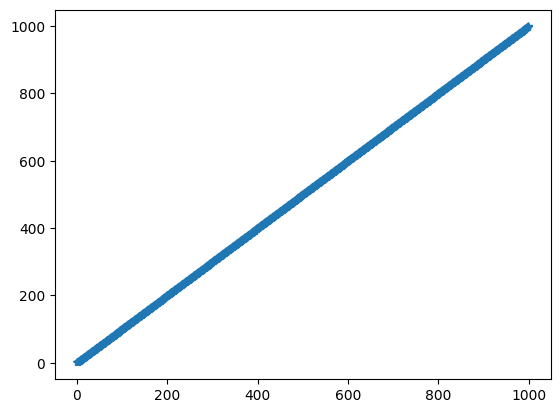

In [3]:
import matplotlib.pyplot as plt
plt.plot(X, y, "*")

In [6]:
model = LinearRegression1D(alpha=0.0000001, num_epochs=100)
model.train(X, y)

In [7]:
model.predict(50)

a=0.9990530933821855, b=0.0014993228607097675


50